In [1]:
"""Домашнее задание - 4 (Поиск информативного скрытого слоя в LLMs)

Задача:
Исследовать распределение информации внутри слоев большой языковой модели (LLM) и определить, какие слои дают наилучшие представления для выбранной задачи (классификация, регрессия или любая другая прикладная цель). Метод основан на идеях A* публикации (HiProbe-VAD (https://arxiv.org/abs/2507.17394)), где показано, что наиболее информативные признаки часто находятся в промежуточных слоях модели

Инструкция:
1. Определить LLM, исходя из доступных вычислительных ресурсов
2. Выбрать корпус (акустический, визуальный, текстовый или мультимодальный), подходящий под задачу
3. Прогнать данные через модель. Для каждого слоя получить нужные представления.
4. Доказать через метрики и визуализацию, какие слои лучшие (тут можно свое авторское придумать и попробовать)
5. На представлениях разных слоев (например топ-3) обучить простой классификатор или регрессор
6. Построить графики/визуализации - номер слоя -> метрика/метрики качества
7. Сделать заключение о том, какие слои оказались наиболее информативными и почему. Сравните промежуточные, начальные и финальные слои.

В итоге
- Код экспериментов (ноутбук или py с полным pipeline)
- Таблица и график с результатами по слоям
- Выводы о том, где в LLM сосредоточены лучшие признаки для выбранной задачи."""

'Домашнее задание - 4 (Поиск информативного скрытого слоя в LLMs)\n\nЗадача:\nИсследовать распределение информации внутри слоев большой языковой модели (LLM) и определить, какие слои дают наилучшие представления для выбранной задачи (классификация, регрессия или любая другая прикладная цель). Метод основан на идеях A* публикации (HiProbe-VAD (https://arxiv.org/abs/2507.17394)), где показано, что наиболее информативные признаки часто находятся в промежуточных слоях модели\n\nИнструкция:\n1. Определить LLM, исходя из доступных вычислительных ресурсов\n2. Выбрать корпус (акустический, визуальный, текстовый или мультимодальный), подходящий под задачу\n3. Прогнать данные через модель. Для каждого слоя получить нужные представления.\n4. Доказать через метрики и визуализацию, какие слои лучшие (тут можно свое авторское придумать и попробовать)\n5. На представлениях разных слоев (например топ-3) обучить простой классификатор или регрессор\n6. Построить графики/визуализации - номер слоя -> метр

In [2]:
import os
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, AutoConfig
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from datasets import load_dataset

assert torch.cuda.is_available(), "CUDA not available"
print(f"✓ Device: {torch.cuda.get_device_name(0)}")
print(f"✓ PyTorch: {torch.__version__}")
print(f"✓ Transformers: {__import__('transformers').__version__}")

✓ Device: Tesla T4
✓ PyTorch: 2.10.0+cu128
✓ Transformers: 5.0.0


In [3]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LENGTH = 512
BATCH_SIZE = 8
LAYERS_TO_PROBE = None  # None = all layers

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
    torch_dtype=torch.float16,  # save VRAM on T4
    device_map=DEVICE
)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2Model(
  (embed_tokens): Embedding(151936, 896)
  (layers): ModuleList(
    (0-23): 24 x Qwen2DecoderLayer(
      (self_attn): Qwen2Attention(
        (q_proj): Linear(in_features=896, out_features=896, bias=True)
        (k_proj): Linear(in_features=896, out_features=128, bias=True)
        (v_proj): Linear(in_features=896, out_features=128, bias=True)
        (o_proj): Linear(in_features=896, out_features=896, bias=False)
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
        (up_proj): Linear(in_features=896, out_features=4864, bias=False)
        (down_proj): Linear(in_features=4864, out_features=896, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((896,), eps=1e-06)
  (rotary_emb): Qwen2RotaryEmbedding()
)

In [5]:
DATASET_NAME = "ag_news"
NUM_SAMPLES = 2000  # subsample for fast prototyping on T4
TEST_SIZE = 0.2
SEED = 42

# Load and subsample dataset
raw_data = load_dataset(DATASET_NAME, split="train")
df = pd.DataFrame(raw_data.select(range(NUM_SAMPLES)))
df = df.rename(columns={"text": "input", "label": "target"})

# Simple train/test split
train_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=SEED, stratify=df["target"]
)

# Tokenize function
def tokenize_batch(texts, tokenizer, max_length=MAX_LENGTH):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [7]:
def extract_layer_representations(model, tokenizer, texts, device, max_length=MAX_LENGTH, layers=None):
    """
    Extract mean-pooled hidden states from specified layers.
    Returns: dict {layer_idx: np.array [n_samples, hidden_size]}
    """
    model.eval()
    encodings = tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encodings, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # tuple of (batch, seq_len, hidden_size)

    # Create attention mask for mean pooling (exclude padding)
    attention_mask = encodings["attention_mask"].unsqueeze(-1)  # [batch, seq, 1]

    layer_reps = {}
    layer_indices = range(len(hidden_states)) if layers is None else layers

    for layer_idx in layer_indices:
        # Mean pooling over non-padded tokens
        h = hidden_states[layer_idx] * attention_mask
        pooled = h.sum(dim=1) / attention_mask.sum(dim=1).clamp(min=1)
        layer_reps[layer_idx] = pooled.cpu().numpy()

    return layer_reps

In [8]:
train_texts = train_df["input"].values
train_labels = train_df["target"].values
num_layers = model.config.num_hidden_layers + 1
BATCH_SIZE = 16

train_representations = {}
print(f"Extracting {num_layers} layers for {len(train_texts)} train samples...")

for layer_idx in range(num_layers):
    layer_reps = []
    for i in range(0, len(train_texts), BATCH_SIZE):
        batch = tokenizer(
            train_texts[i:i+BATCH_SIZE].tolist(),
            padding=True, truncation=True, max_length=MAX_LENGTH,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            out = model(**batch, output_hidden_states=True)
            h = out.hidden_states[layer_idx]

        mask = batch["attention_mask"].unsqueeze(-1)
        pooled = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        layer_reps.append(pooled.cpu().numpy())

        del out, h, mask, batch, pooled
        torch.cuda.empty_cache()

    train_representations[layer_idx] = np.vstack(layer_reps)
    if layer_idx % 5 == 0:
        print(f"  Layer {layer_idx} done")

gc.collect()

Extracting 25 layers for 1600 train samples...
  Layer 0 done
  Layer 5 done
  Layer 10 done
  Layer 15 done
  Layer 20 done


252

In [10]:
test_texts = test_df["input"].values
test_labels = test_df["target"].values

test_representations = {}
print(f"Extracting {num_layers} layers for {len(test_texts)} test samples...")

for layer_idx in range(num_layers):
    layer_reps = []
    for i in range(0, len(test_texts), BATCH_SIZE):
        batch = tokenizer(
            test_texts[i:i+BATCH_SIZE].tolist(),
            padding=True, truncation=True, max_length=MAX_LENGTH,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            out = model(**batch, output_hidden_states=True)
            h = out.hidden_states[layer_idx]

        mask = batch["attention_mask"].unsqueeze(-1)
        pooled = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        layer_reps.append(pooled.cpu().numpy())

        del out, h, mask, batch, pooled
        torch.cuda.empty_cache()

    test_representations[layer_idx] = np.vstack(layer_reps)
    if layer_idx % 5 == 0:
        print(f"  Layer {layer_idx} done")

gc.collect()

Extracting 25 layers for 400 test samples...
  Layer 0 done
  Layer 5 done
  Layer 10 done
  Layer 15 done
  Layer 20 done


0

In [12]:
results = []

for layer_idx in range(num_layers):
    X_train = train_representations[layer_idx]
    X_test = test_representations[layer_idx]

    clf = LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        solver="lbfgs",
        multi_class="multinomial"
    )
    clf.fit(X_train, train_labels)
    preds = clf.predict(X_test)

    acc = accuracy_score(test_labels, preds)
    f1 = f1_score(test_labels, preds, average="macro")

    results.append({
        "layer": layer_idx,
        "accuracy": acc,
        "f1_macro": f1
    })

    if layer_idx % 5 == 0:
        print(f"Layer {layer_idx}: acc={acc:.3f}, f1={f1:.3f}")

results_df = pd.DataFrame(results)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Layer 0: acc=0.388, f1=0.140


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Layer 5: acc=0.877, f1=0.875


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'mul

...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mo

Layer 15: acc=0.880, f1=0.877


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Layer 20: acc=0.873, f1=0.870


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

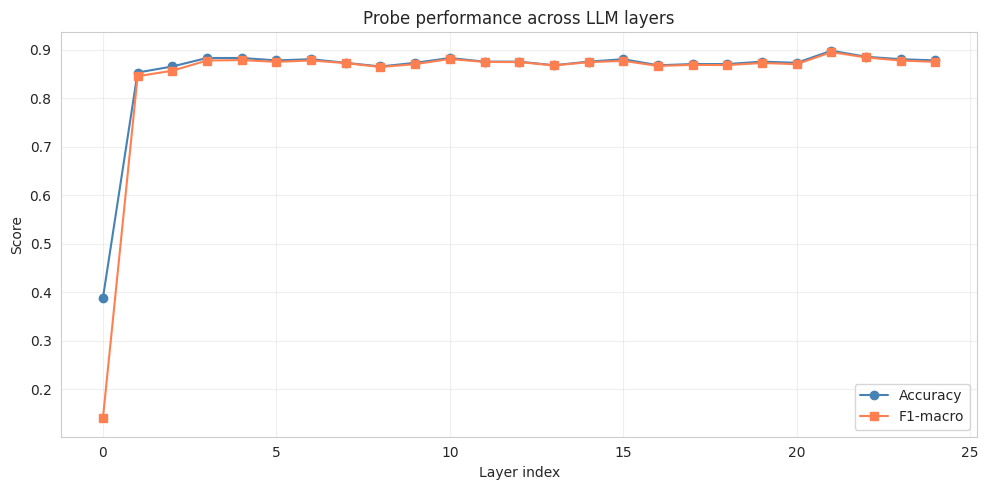

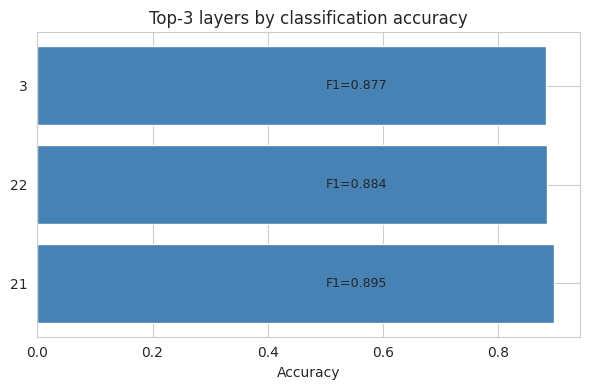

In [14]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Plot 1: Accuracy & F1 across layers
fig, ax1 = plt.subplots()
ax1.plot(results_df["layer"], results_df["accuracy"], label="Accuracy", color="steelblue", marker="o")
ax1.plot(results_df["layer"], results_df["f1_macro"], label="F1-macro", color="coral", marker="s")
ax1.set_xlabel("Layer index")
ax1.set_ylabel("Score")
ax1.set_title("Probe performance across LLM layers")
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Top-3 layers bar chart
top3 = results_df.nlargest(3, "accuracy")
plt.figure(figsize=(6, 4))
plt.barh(top3["layer"].astype(str), top3["accuracy"], color="steelblue")
plt.xlabel("Accuracy")
plt.title("Top-3 layers by classification accuracy")
for i, (acc, f1) in enumerate(zip(top3["accuracy"], top3["f1_macro"])):
    plt.text(0.5, i, f"F1={f1:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2773: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))


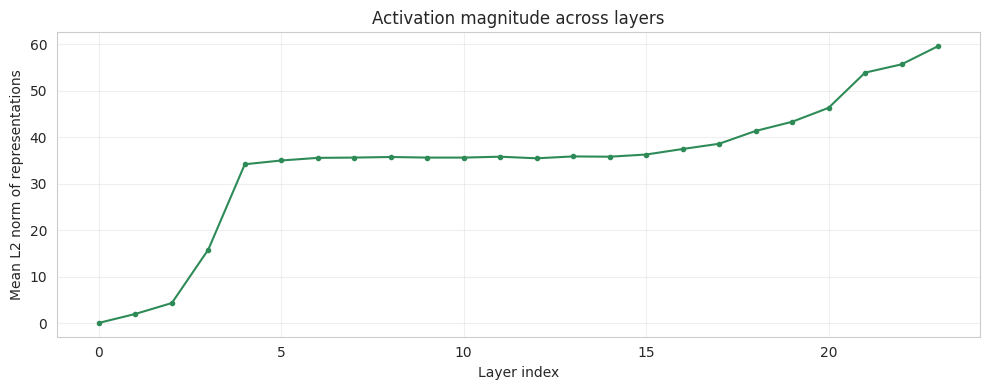

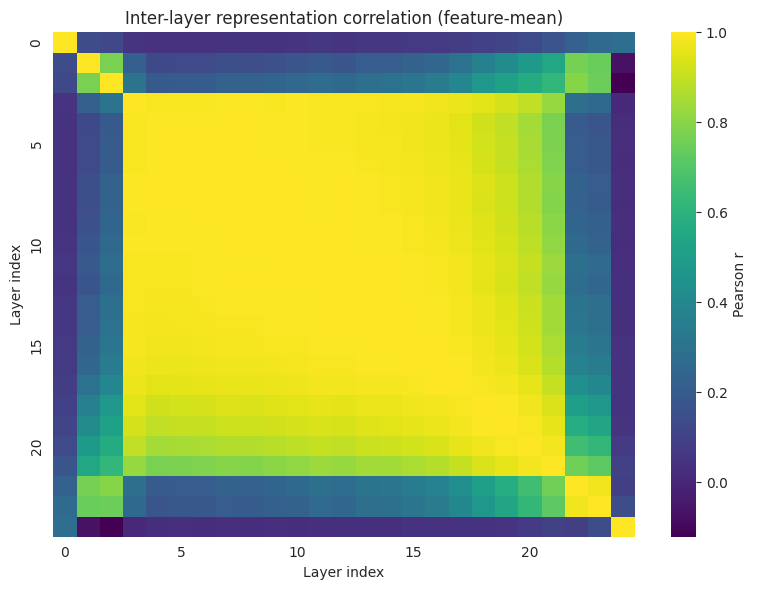

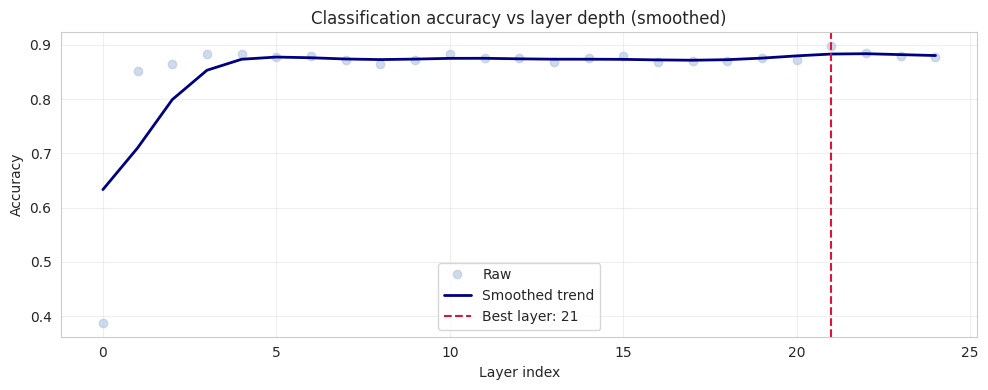

In [16]:
from scipy.ndimage import gaussian_filter1d

# Plot 3: Representation norm across layers (mean L2 norm per sample)
layer_norms = []
for layer_idx in range(num_layers):
    norms = np.linalg.norm(train_representations[layer_idx], axis=1)
    layer_norms.append(norms.mean())

plt.figure(figsize=(10, 4))
plt.plot(results_df["layer"], layer_norms, color="seagreen", marker=".", linewidth=1.5)
plt.xlabel("Layer index")
plt.ylabel("Mean L2 norm of representations")
plt.title("Activation magnitude across layers")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 4: Correlation heatmap between layer representations (subsample for speed)
sample_idx = np.random.choice(len(train_representations[0]), 200, replace=False)
corr_matrix = np.zeros((num_layers, num_layers))
for i in range(num_layers):
    for j in range(i, num_layers):
        Xi = train_representations[i][sample_idx]
        Xj = train_representations[j][sample_idx]
        # Centered correlation
        corr = np.corrcoef(Xi.mean(axis=0), Xj.mean(axis=0))[0, 1]
        corr_matrix[i, j] = corr_matrix[j, i] = corr if not np.isnan(corr) else 0

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap="viridis", xticklabels=5, yticklabels=5, cbar_kws={"label": "Pearson r"})
plt.xlabel("Layer index")
plt.ylabel("Layer index")
plt.title("Inter-layer representation correlation (feature-mean)")
plt.tight_layout()
plt.show()

# Plot 5: Smoothed accuracy trend with confidence interval (bootstrap-like)
smooth_acc = gaussian_filter1d(results_df["accuracy"].values, sigma=1.5)
plt.figure(figsize=(10, 4))
plt.plot(results_df["layer"], results_df["accuracy"], "o", color="lightsteelblue", label="Raw", alpha=0.6)
plt.plot(results_df["layer"], smooth_acc, "-", color="navy", label="Smoothed trend", linewidth=2)
plt.axvline(x=results_df.loc[results_df["accuracy"].idxmax(), "layer"],
            color="crimson", linestyle="--", label=f"Best layer: {results_df['accuracy'].idxmax()}")
plt.xlabel("Layer index")
plt.ylabel("Accuracy")
plt.title("Classification accuracy vs layer depth (smoothed)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
"""ВЫВОДЫ

Самыми полезными с точки зрения информативности получились слои 21-22, т.к скорее всего в финальных слоях находятся
важные для нашей задачи признаки.

На одном из графиков мы видем резкий скачок по точности в районе 4 слоя , предполагаю что именно с этого момента модель начинает
улавливать семантические зависимости.
До 5-го слоя модель  извлекает лишь незначительные признаки

Итогом с тало что лучше всего для задачи классификации использовать слои 21-22

Удобно если хотим использовать LoRa адаптеры и дообучать лишь конкретные слои

"""

'ВЫВОДЫ\n\nСамыми полезными с точки зрения информативности получились слои 21-22, т.к скорее всего в финальных слоях находятся \nважные для нашей задачи признаки. \n\nНа одном из графиков мы видем резкий скачок по точности в районе 4 слоя , предполагаю что именно с этого момента модель начинает \nулавливать семантические зависимости.\nДо 5-го слоя модель  извлекает лишь незначительные признаки\n\nИтогом с тало что лучше всего для задачи классификации использовать слои 21-22\n\nУдобно если хотим использовать LoRa адаптеры и дообучать лишь конкретные слои\n\n'